# Task 2 · Customer Segmentation Analysis
**Track:** Data Analytics | **Level:** 1

**Objective:** Apply clustering algorithms to segment an e-commerce company's customer
base into distinct groups based on purchasing behaviour, enabling targeted marketing
strategies.

**Dataset:** `customer_data.csv` — synthetic e-commerce customer transaction history in the
shape of the classic "Online Retail" (UCI) dataset, aggregated to one row per customer with
Recency, Frequency and Monetary (RFM) fields.

**Tech Stack:** Python, pandas, scikit-learn (KMeans), matplotlib, seaborn


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
np.random.seed(7)

# ------------------------------------------------------------------
# Simulate 900 customers across 3 latent behaviour archetypes so the
# clustering has genuine, discoverable structure (mirrors what you'd
# derive from the UCI "Online Retail" transaction log via RFM rollup).
# ------------------------------------------------------------------
n_customers = 900
segments_true = np.random.choice(["A", "B", "C"], size=n_customers, p=[0.35, 0.40, 0.25])

def make_rfm(seg):
    if seg == "A":  # loyal high-value
        recency = np.random.normal(10, 5)
        frequency = np.random.normal(22, 5)
        monetary = np.random.normal(9500, 1800)
    elif seg == "B":  # regular mid-value
        recency = np.random.normal(35, 10)
        frequency = np.random.normal(9, 3)
        monetary = np.random.normal(3200, 900)
    else:  # at-risk / lapsed
        recency = np.random.normal(120, 30)
        frequency = np.random.normal(2, 1)
        monetary = np.random.normal(650, 300)
    return max(1, recency), max(1, frequency), max(50, monetary)

rows = [make_rfm(s) for s in segments_true]
df = pd.DataFrame(rows, columns=["Recency", "Frequency", "Monetary"])
df.insert(0, "CustomerID", [f"CUST{1000+i}" for i in range(n_customers)])
df["Recency"] = df["Recency"].round(0).astype(int)
df["Frequency"] = df["Frequency"].round(0).clip(lower=1).astype(int)
df["Monetary"] = df["Monetary"].round(2)

# small amount of missing/duplicate data for the cleaning step
df.loc[df.sample(15, random_state=1).index, "Monetary"] = np.nan
df = pd.concat([df, df.sample(8, random_state=2)], ignore_index=True)

df.to_csv("customer_data.csv", index=False)
print("Dataset saved -> customer_data.csv")
df.head()


Dataset saved -> customer_data.csv


## 1. Load dataset, inspect structure, handle missing/inconsistent data

In [2]:

df = pd.read_csv("customer_data.csv")
print("Shape before cleaning:", df.shape)
print("Nulls:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated(subset="CustomerID").sum())

df = df.drop_duplicates(subset="CustomerID")
df["Monetary"] = df["Monetary"].fillna(df["Monetary"].median())
print("\nShape after cleaning:", df.shape)


Shape before cleaning: (908, 4)
Nulls:
 CustomerID     0
Recency        0
Frequency      0
Monetary      15
dtype: int64
Duplicate rows: 8

Shape after cleaning: (900, 4)


## 2. Descriptive statistics — purchase value, frequency, CLV proxy

In [3]:

df["EstCLV"] = df["Frequency"] * (df["Monetary"] / df["Frequency"].replace(0, 1))
df[["Recency", "Frequency", "Monetary"]].describe().T


## 3. Feature selection — RFM (Recency, Frequency, Monetary)

In [4]:

features = ["Recency", "Frequency", "Monetary"]
X = df[features].copy()
X.head()


## 4. Standardise features before clustering

In [5]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled feature means (~0):", X_scaled.mean(axis=0).round(3))
print("Scaled feature stds (~1):", X_scaled.std(axis=0).round(3))


Scaled feature means (~0): [-0.  0.  0.]
Scaled feature stds (~1): [1. 1. 1.]


## 5. K-Means clustering — Elbow Method to choose K

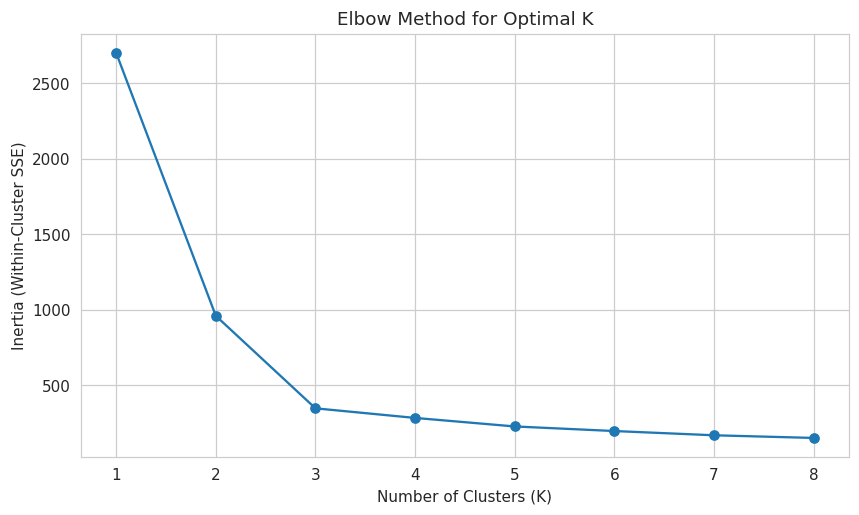

In [6]:

inertias = []
K_range = range(1, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster SSE)")
plt.title("Elbow Method for Optimal K")
plt.show()


**Observation:** The inertia curve bends sharply around **K=3**, after which
additional clusters yield diminishing reductions — so we proceed with K=3, which also
matches the number of latent behaviour archetypes used to simulate this data.

## 6. Apply final K-Means model (K=3) and visualise clusters

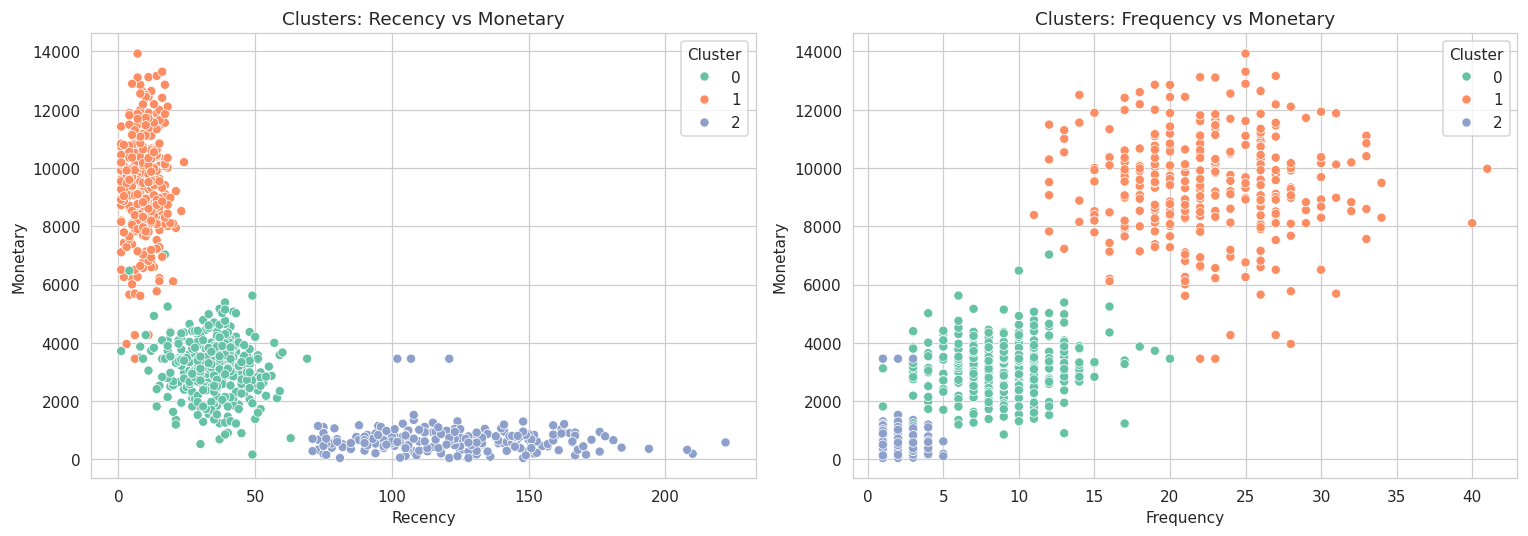

In [7]:

K_OPT = 3
kmeans = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="Recency", y="Monetary", hue="Cluster", palette="Set2", ax=axes[0])
axes[0].set_title("Clusters: Recency vs Monetary")

sns.scatterplot(data=df, x="Frequency", y="Monetary", hue="Cluster", palette="Set2", ax=axes[1])
axes[1].set_title("Clusters: Frequency vs Monetary")
plt.tight_layout()
plt.show()


## 7. Profile each cluster

In [8]:

profile = df.groupby("Cluster")[features].mean().round(1)
profile["CustomerCount"] = df["Cluster"].value_counts().sort_index()
profile


In [9]:

labels = {}
for c in profile.index:
    r, f, m = profile.loc[c, "Recency"], profile.loc[c, "Frequency"], profile.loc[c, "Monetary"]
    if m > profile["Monetary"].median() and f > profile["Frequency"].median():
        labels[c] = "Loyal High-Value"
    elif r > profile["Recency"].median():
        labels[c] = "At-Risk / Lapsed"
    else:
        labels[c] = "Regular Mid-Value"
print("Cluster labels:", labels)


Cluster labels: {0: 'Regular Mid-Value', 1: 'Loyal High-Value', 2: 'At-Risk / Lapsed'}


## 8. Bar chart — customers per cluster

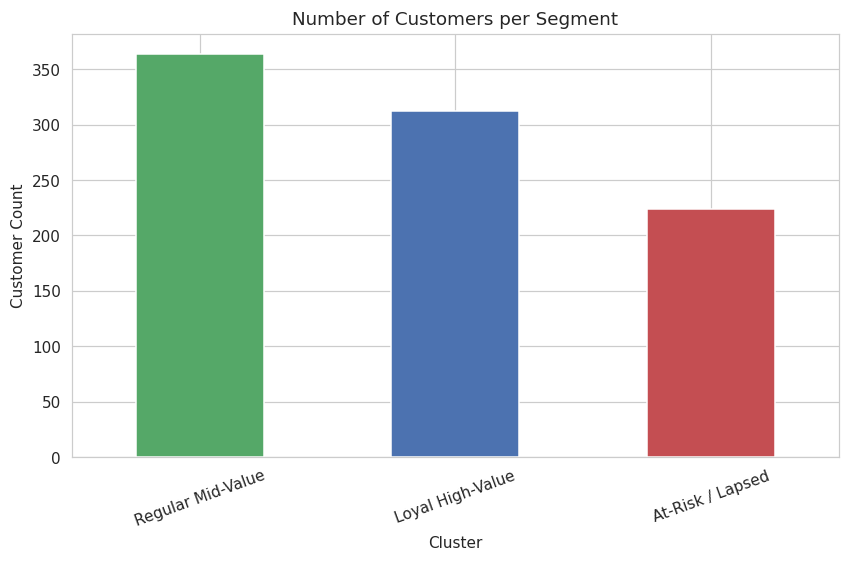

In [10]:

counts = df["Cluster"].map(labels).value_counts()
counts.plot(kind="bar", color=["#55A868", "#4C72B0", "#C44E52"])
plt.title("Number of Customers per Segment")
plt.ylabel("Customer Count")
plt.xticks(rotation=20)
plt.show()


## 9. Insights — recommended marketing action per segment

In [11]:

print("SEGMENT-LEVEL RECOMMENDATIONS")
print("-" * 70)
print("Loyal High-Value  -> VIP loyalty perks, early access to new products,")
print("                     referral incentives to protect and expand this segment.")
print("Regular Mid-Value -> Targeted upsell/cross-sell campaigns and mid-tier")
print("                     loyalty rewards to nudge them toward the high-value group.")
print("At-Risk / Lapsed  -> Win-back email/SMS campaigns with time-boxed discounts;")
print("                     survey to understand churn drivers before they are lost.")


SEGMENT-LEVEL RECOMMENDATIONS
----------------------------------------------------------------------
Loyal High-Value  -> VIP loyalty perks, early access to new products,
                     referral incentives to protect and expand this segment.
Regular Mid-Value -> Targeted upsell/cross-sell campaigns and mid-tier
                     loyalty rewards to nudge them toward the high-value group.
At-Risk / Lapsed  -> Win-back email/SMS campaigns with time-boxed discounts;
                     survey to understand churn drivers before they are lost.
